In [224]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [225]:
import torch
import torchvision
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torch.utils.data as dataloader
import torch.nn as nn

In [226]:
transformation_operation = transforms.Compose([transforms.ToTensor()])

In [227]:
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform= transformation_operation)
val_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform= transformation_operation)

In [228]:
batch_size = 64
num_classes = 10
img_size = 28
patch_size = 7
patch_num = (img_size // patch_size) * (img_size // patch_size)
attention_heads = 4
embed_dim = 16
transformer_blocks = 4
mlp_nodes = 64
num_channels = 1
learning_rate = 0.01
epochs = 5

In [229]:
train_data = dataloader.DataLoader(train_dataset, shuffle = True, batch_size = batch_size)
val_data = dataloader.DataLoader(val_dataset, shuffle = True, batch_size = batch_size)

In [230]:
# to print dimensions
images, labels = next(iter(train_data))
print(images.shape)
patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size = patch_size, stride = patch_size)
embedded_image = patch_embed(images)
print(embedded_image.shape)
print(embedded_image.flatten(2).shape)
print(embedded_image.flatten(2).transpose(1,2).shape)

torch.Size([64, 1, 28, 28])
torch.Size([64, 16, 4, 4])
torch.Size([64, 16, 16])
torch.Size([64, 16, 16])


In [231]:
# class for patch embedding - part 1 of ViT architecture
class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size = patch_size, stride = patch_size)

    def forward(self,x):
        x = self.patch_embed(x)
        x = x.flatten(2)
        x = x.transpose(1,2)
        return x

In [232]:
# class for transformer encoder - part 2 of the ViT architecture
# Layer normalization
# Multi head attention
# Layer normalization
# Residuals
# MLP - activation function

class TransformerEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.multi_head_attention = nn.MultiheadAttention(embed_dim, attention_heads, batch_first= True)
        self.layer_norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_nodes),
            nn.GELU(),
            nn.Linear(mlp_nodes, embed_dim)
            # nn.GELU(),
            # nn.Linear(embed_dim)
        )

    def forward(self, x):
        residual1 = x
        x = self.layer_norm1(x)
        x = self.multi_head_attention(x, x, x)[0] + residual1
        residual2 = x
        x = self.layer_norm2(x)
        x = self.mlp(x) + residual2
        return x

In [233]:
# class for MLP head for classification - part 3 of the ViT architecture
class MLP_Head(nn.Module):
    def __init__(self):
        super().__init__()
        self.layernorm3 = nn.LayerNorm(embed_dim)
        self.mlphead = nn.Sequential(
            # nn.Linear(embed_dim)
            nn.Linear(embed_dim, num_classes)
        )
    def forward(self, x):
        # x = x[:,0]
        x = self.layernorm3(x)
        x = self.mlphead(x)
        return x

In [234]:
class VisionTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embedding = PatchEmbedding()
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.positional_embedding = nn.Parameter(torch.randn(1, patch_num + 1, embed_dim))
        self.transformer_blocks = nn.Sequential(*[TransformerEncoder() for _ in range(transformer_blocks)])
        self.mlp_head = MLP_Head() 
    def forward(self,x):
        x = self.patch_embedding(x)
        B = x.shape[0]
        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), 1)
        x = x + self.positional_embedding
        x = self.transformer_blocks(x)
        x = x[:,0]
        x = self.mlp_head(x)
        return x

In [235]:
# device
# optimizer
# cross entropy
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = VisionTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
criterion = nn.CrossEntropyLoss()

In [236]:
for epoch in range(5):
    model.train()
    total_loss = 0
    correct_epoch = 0
    total_epoch = 0
    print(f"\nEpoch {epoch+1}")

    for batch_idx, (images, labels) in enumerate(train_data):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss+=loss.item()
        preds = outputs.argmax(dim=1)

        correct = (preds == labels).sum().item()
        accuracy = 100.0 * correct / labels.size(0)

        correct_epoch += correct
        total_epoch += labels.size(0)

        if batch_idx % 100 == 0:
            print(f"  Batch {batch_idx+1:3d}: Loss = {loss.item():.4f}, Accuracy = {accuracy:.2f}%")

    epoch_acc = 100.0 * correct_epoch / total_epoch
    print(f"==> Epoch {epoch+1} Summary: Total Loss = {total_loss:.4f}, Accuracy = {epoch_acc:.2f}%")


Epoch 1
  Batch   1: Loss = 2.3598, Accuracy = 12.50%
  Batch 101: Loss = 0.8294, Accuracy = 76.56%
  Batch 201: Loss = 0.7424, Accuracy = 81.25%
  Batch 301: Loss = 0.2930, Accuracy = 90.62%
  Batch 401: Loss = 0.2526, Accuracy = 92.19%
  Batch 501: Loss = 0.1677, Accuracy = 96.88%
  Batch 601: Loss = 0.3117, Accuracy = 90.62%
  Batch 701: Loss = 0.3771, Accuracy = 90.62%
  Batch 801: Loss = 0.2923, Accuracy = 93.75%
  Batch 901: Loss = 0.3145, Accuracy = 92.19%
==> Epoch 1 Summary: Total Loss = 495.3470, Accuracy = 82.48%

Epoch 2
  Batch   1: Loss = 0.2208, Accuracy = 93.75%
  Batch 101: Loss = 0.3009, Accuracy = 90.62%
  Batch 201: Loss = 0.2233, Accuracy = 90.62%
  Batch 301: Loss = 0.2048, Accuracy = 92.19%
  Batch 401: Loss = 0.2664, Accuracy = 87.50%
  Batch 501: Loss = 0.0762, Accuracy = 96.88%
  Batch 601: Loss = 0.1724, Accuracy = 92.19%
  Batch 701: Loss = 0.0395, Accuracy = 98.44%
  Batch 801: Loss = 0.2357, Accuracy = 87.50%
  Batch 901: Loss = 0.2920, Accuracy = 92.19%


In [237]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_data:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = 100.0 * correct / total
print(f"\n==> Val Accuracy: {test_acc:.2f}%")


==> Val Accuracy: 96.89%


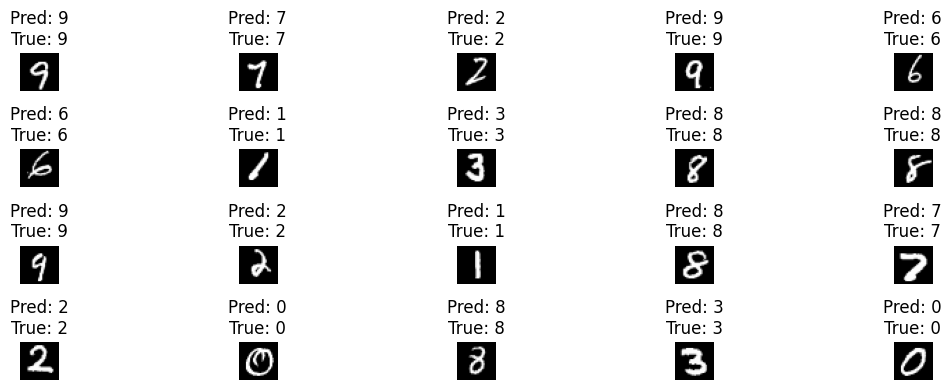

In [238]:
model.eval()
images, labels = next(iter(val_data))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

# Plot 10 test images with predictions
plt.figure(figsize=(12, 4))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()